# Caso BodyFat
### Prediccion de grasa corporal con CRISP-DM

**Estudiante:** Tayron David Cuellar Arteaga

**Materia:** Inteligencia Artificial

**Dataset:** bodyfat.csv

**Fecha:** 2026-05-15

---

**Idea central:** usamos medidas anatomicas simples para explicar y predecir
el porcentaje de grasa corporal, con narrativa clara y visualizaciones
comentadas en estilo revista.

## Objetivos del notebook

- Presentar el caso BodyFat siguiendo CRISP-DM (Fases 1 a 3).
- Explicar el dataset con unidades y variables anatomicas.
- Realizar exploracion y preparacion con criterios claros.
- Mantener narrativa tipo revista: contexto antes del codigo y
  interpretacion despues de cada figura o tabla.

**Alcance del examen:** se trabajan Fase 1 (Business Understanding),
Fase 2 (Data Understanding) y Fase 3 (Data Preparation).

## Mapa CRISP-DM (orden del notebook)

| Fase | Que haremos | Entregable clave |
|------|-------------|------------------|
| 1. Business Understanding | Contexto, objetivo, criterios y variables | Objetivo y mapa del caso |
| 2. Data Understanding | Carga, estructura, EDA, correlaciones y anomalias | Hallazgos y top 3 medidas |
| 3. Data Preparation | Duplicados, capping IQR, seleccion, split y escalado | Dataset listo para modelar |
| 4. Modeling | Regresion (lineal, RF, XGB) y clasificacion (logistica, RF, XGB) | Modelos entrenados |
| 5. Evaluation | MAE y $R^2$ en regresion; F1 y matriz de confusion en clasificacion | Comparacion y mejor modelo |
| 6. Deployment | Reflexion y recomendaciones finales | Cierre del caso |

> **Nota:** el examen se centra en Fases 1 a 3, pero mantenemos el flujo completo
para ordenar el trabajo segun CRISP-DM.

## Fase 1: Business Understanding — Contexto y objetivo

En esta fase definimos el problema del negocio, el objetivo analitico y
las variables disponibles. La pregunta guia es:
**podemos estimar BodyFat con medidas simples y accesibles?**

### Dataset bodyfat.csv (variables y unidades)

Este dataset proviene del clasico estudio Body Fat (UCI).
La variable objetivo es **BodyFat** (porcentaje de grasa corporal).
La variable **Density** proviene de laboratorio y se usa para calcular
BodyFat, por lo que se considera leakage si se usa como predictor.

| Variable | Descripcion | Unidad |
|----------|-------------|--------|
| Density | Densidad corporal | g/cm^3 |
| BodyFat | Porcentaje de grasa corporal | % |
| Age | Edad | anos |
| Weight | Peso | lb |
| Height | Estatura | pulgadas |
| Neck | Perimetro de cuello | cm |
| Chest | Perimetro de pecho | cm |
| Abdomen | Perimetro de abdomen | cm |
| Hip | Perimetro de cadera | cm |
| Thigh | Perimetro de muslo | cm |
| Knee | Perimetro de rodilla | cm |
| Ankle | Perimetro de tobillo | cm |
| Biceps | Perimetro de biceps | cm |
| Forearm | Perimetro de antebrazo | cm |
| Wrist | Perimetro de muneca | cm |

En las siguientes secciones cargaremos el dataset, validaremos calidad
y construiremos visualizaciones clave para entender las relaciones
anatomicas con BodyFat.

---
## Preparacion del entorno y estilo visual

Antes de analizar el dataset, cargamos librerias base y definimos
un estilo visual consistente. Esto ayuda a que todas las figuras
tengan una identidad comun y sean faciles de comparar.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "primary": "#1f77b4",
    "accent": "#ff7f0e",
    "ok": "#2ca02c",
    "neutral": "#7f7f7f",
}
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Librerias cargadas y estilo configurado.")

Librerias cargadas y estilo configurado.


Si aparece el mensaje **"Librerias cargadas y estilo configurado."**,
puedes continuar con la carga del dataset.

---
## Fase 2: Data Understanding — Carga y estructura

Abrimos el archivo CSV y miramos las primeras filas para confirmar que
los datos se leen bien, revisar columnas y tener una primera impresion
del formato.

In [25]:
df = pd.read_csv("bodyfat.csv")

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")

df.head(8)

Dimensiones: 252 filas x 15 columnas
Columnas: ['Density', 'BodyFat', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
5,1.0502,20.9,24,210.25,74.75,39.0,104.5,94.4,107.8,66.0,42.0,25.6,35.7,30.6,18.8
6,1.0549,19.2,26,181.00,69.75,36.4,105.1,90.7,100.3,58.4,38.3,22.9,31.9,27.8,17.7
7,1.0704,12.4,25,176.00,72.50,37.8,99.6,88.5,97.1,60.0,39.4,23.2,30.5,29.0,18.8


**Interpretacion rapida:**
- El dataset contiene observaciones individuales con medidas corporales.
- Todas las columnas son numericas, lo que simplifica el preprocesamiento.
- Confirmamos que el archivo se cargo sin cambios en los nombres de variables.

### Estructura, tipos y calidad basica

Aqui revisamos tipos de dato, valores faltantes y duplicados.
Es la inspeccion minima para confiar en los siguientes analisis.

In [26]:
tipos = df.dtypes.to_frame("dtype")
faltantes = df.isna().sum()
resumen_calidad = tipos.join(faltantes.rename("missing"))
resumen_calidad["missing_%"] = (resumen_calidad["missing"] / len(df) * 100).round(2)

dup = int(df.duplicated().sum())
print(f"Duplicados: {dup}")

resumen_calidad

Duplicados: 0


,dtype,missing,missing_%
Density,float64,0,0.0
BodyFat,float64,0,0.0
Age,int64,0,0.0
Weight,float64,0,0.0
Height,float64,0,0.0
Neck,float64,0,0.0
Chest,float64,0,0.0
Abdomen,float64,0,0.0
Hip,float64,0,0.0
Thigh,float64,0,0.0


**Interpretacion:**
- Esperamos 0 faltantes en la mayoria de columnas (dataset limpio).
- Si hay duplicados, se eliminaran en la fase de preparacion.
- Todos los campos son numericos, no hace falta codificacion categorica.

### Glosario anatomico (referencia rapida)

| Variable | Zona anatomica | Comentario |
|----------|-----------------|------------|
| Neck | Cuello | Perimetro a la altura del cuello |
| Chest | Pecho | Perimetro toracico |
| Abdomen | Abdomen | Perimetro abdominal (zona umbilical) |
| Hip | Cadera | Perimetro de cadera |
| Thigh | Muslo | Perimetro del muslo medio |
| Knee | Rodilla | Perimetro a la altura de la rodilla |
| Ankle | Tobillo | Perimetro del tobillo |
| Biceps | Brazo | Perimetro de biceps relajado |
| Forearm | Antebrazo | Perimetro del antebrazo |
| Wrist | Muneca | Perimetro de la muneca |

**Notas de unidades:** Weight esta en libras (lb), Height en pulgadas,
y los perimetros en centimetros (cm).

### Tabla de resumen numerico

Para tener una vision global del dataset, resumimos media, dispersion
y rango de cada variable. Esto ayuda a detectar escalas muy distintas
y valores extremos desde el inicio.

In [27]:
resumen = df.describe().T
resumen["range"] = resumen["max"] - resumen["min"]

resumen = resumen[["mean", "std", "min", "25%", "50%", "75%", "max", "range"]].round(2)
resumen

,mean,std,min,25%,50%,75%,max,range
Density,1.06,0.02,1.0,1.04,1.05,1.07,1.11,0.11
BodyFat,19.15,8.37,0.0,12.48,19.20,25.30,47.50,47.50
Age,44.88,12.60,22.0,35.75,43.00,54.00,81.00,59.00
Weight,178.92,29.39,118.5,159.00,176.50,197.00,363.15,244.65
Height,70.15,3.66,29.5,68.25,70.00,72.25,77.75,48.25
Neck,37.99,2.43,31.1,36.40,38.00,39.42,51.20,20.10
Chest,100.82,8.43,79.3,94.35,99.65,105.38,136.20,56.90
Abdomen,92.56,10.78,69.4,84.57,90.95,99.32,148.10,78.70
Hip,99.90,7.16,85.0,95.50,99.30,103.52,147.70,62.70
Thigh,59.41,5.25,47.2,56.00,59.00,62.35,87.30,40.10


**Interpretacion:**
- BodyFat suele tener dispersion amplia, lo que justifica modelos flexibles.
- Las medidas de perimetro comparten escalas similares (cm), mientras que
  Weight y Height tienen unidades distintas y rangos propios.
- Este resumen nos prepara para estandarizar en fases posteriores.

---
## Fase 2: Data Understanding — Analisis Exploratorio (EDA)

En esta fase exploramos estructura, distribuciones, correlaciones y anomalias
para comprender el comportamiento del dataset antes de modelar.
La prioridad es identificar las **tres medidas con mayor relacion lineal**.

### 1.1 Matriz de correlacion (Pearson)

Esta matriz resume la relacion lineal entre todas las variables.
Una escala en rojo indica correlacion positiva (a mayor X, mayor BodyFat)
y azul negativa (a mayor X, menor BodyFat).

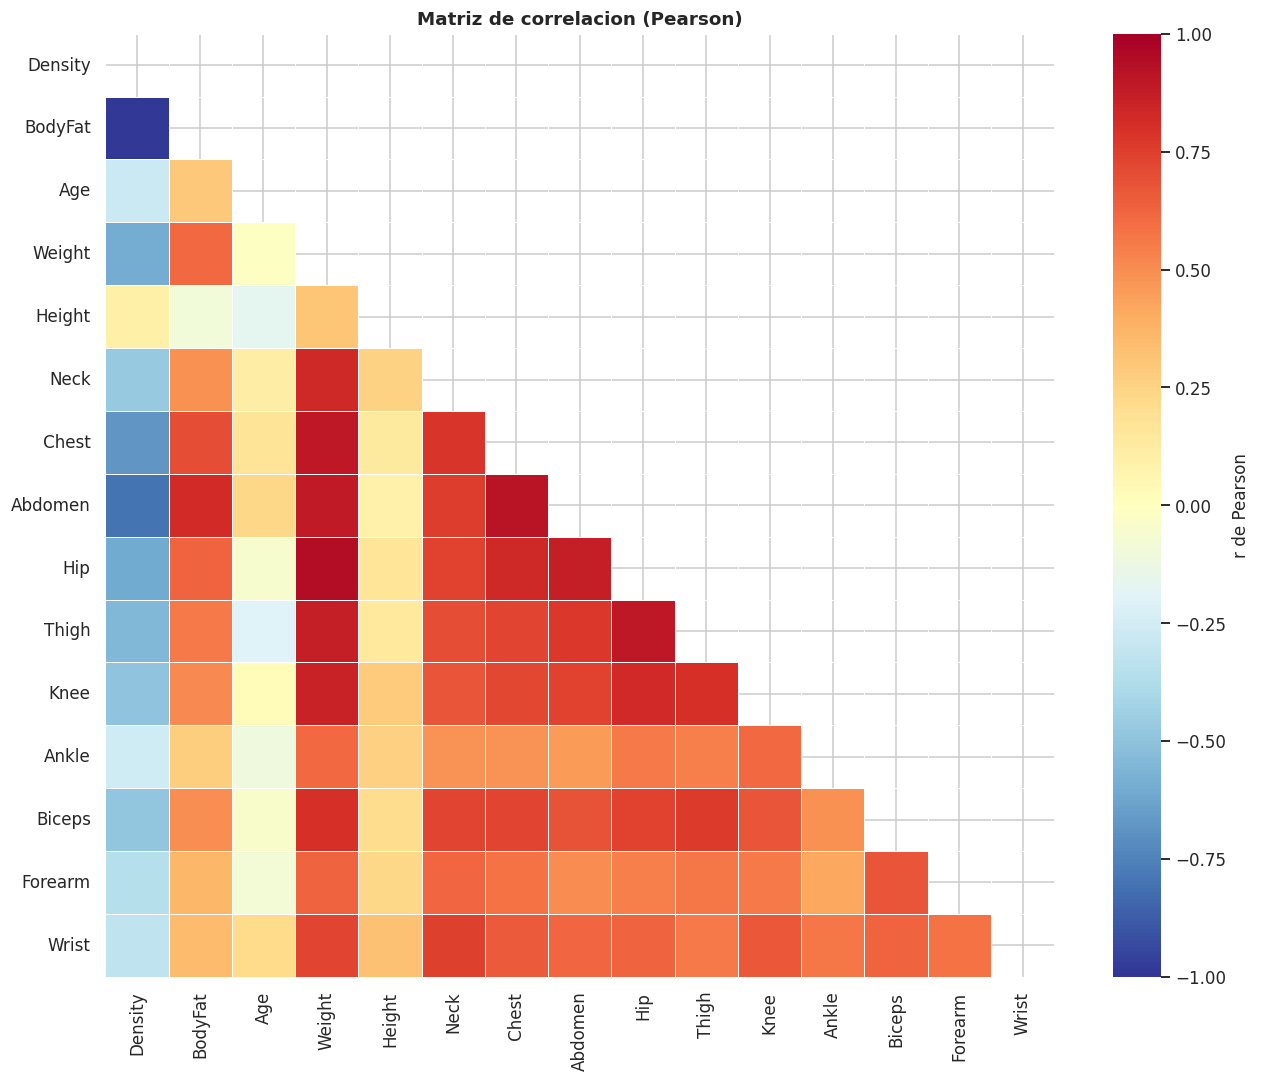

In [28]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, mask=mask, cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white", cbar_kws={"label": "r de Pearson"},
    ax=ax
 )
ax.set_title("Matriz de correlacion (Pearson)", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretacion:**
- Los bloques mas intensos indican relaciones lineales fuertes.
- Si BodyFat tiene correlacion alta con algun perimetro, esa zona es candidata
  a ser medida prioritaria en el gimnasio.
- Density debe interpretarse con cuidado porque es la variable de laboratorio
  que explica BodyFat por definicion (posible leakage).

### 1.2 Ranking de medidas anatomicas vs BodyFat

Ahora aislamos solo las variables anatomicas (excluyendo Density) y
ordenamos por la fuerza de su correlacion con BodyFat.
El objetivo es quedarnos con el **top 3** de medidas mas informativas.

Top 3 medidas anatomicas (por |r|):


,r,abs_r
Abdomen,0.813432,0.813432
Chest,0.702620,0.702620
Hip,0.625201,0.625201


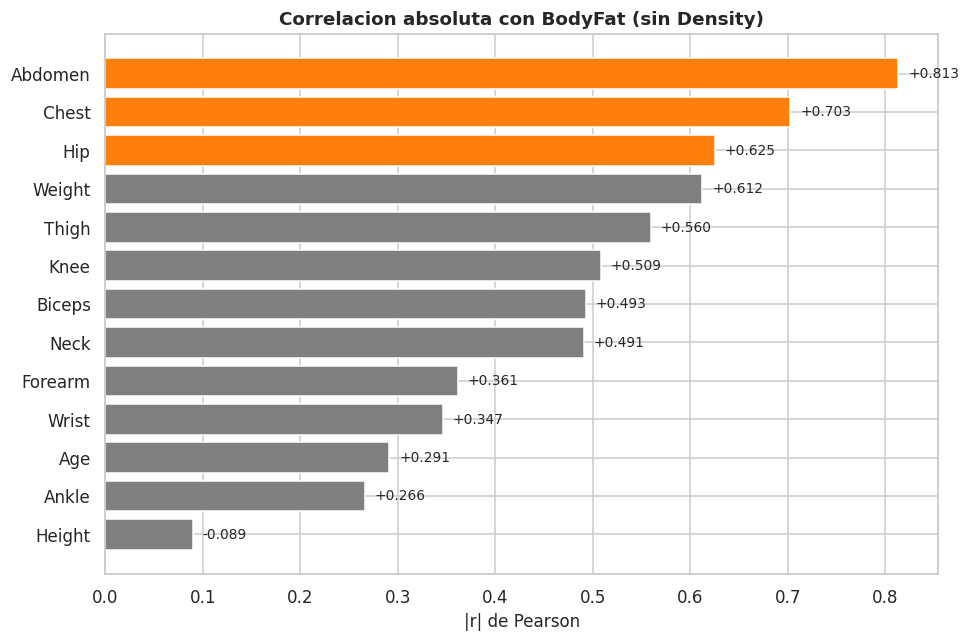

In [29]:
target_corr = corr["BodyFat"].drop(["BodyFat", "Density"], errors="ignore")
rank_tbl = target_corr.to_frame("r")
rank_tbl["abs_r"] = rank_tbl["r"].abs()
rank_tbl = rank_tbl.sort_values("abs_r", ascending=True)

top3 = rank_tbl.tail(3).sort_values("abs_r", ascending=False)
print("Top 3 medidas anatomicas (por |r|):")
display(top3)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [COLORS["accent"] if f in top3.index else COLORS["neutral"] for f in rank_tbl.index]
ax.barh(rank_tbl.index, rank_tbl["abs_r"], color=colors, edgecolor="white")
ax.set_title("Correlacion absoluta con BodyFat (sin Density)", fontweight="bold")
ax.set_xlabel("|r| de Pearson")
for i, (feat, row) in enumerate(rank_tbl.iterrows()):
    ax.text(row["abs_r"] + 0.01, i, f"{row['r']:+.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretacion:**
- El top 3 resalta las zonas anatomicas mas asociadas a BodyFat.
- En el grafico, el color naranja marca las variables mas influyentes.
- Este ranking se usara para responder la pregunta de "una sola medida" en la
  seccion de reflexion.

### 1.3 Dispersión del top 3 (relacion visual)

El ranking muestra fuerza lineal, pero los scatter plots revelan
si la relacion es estable o si hay dispersion elevada.

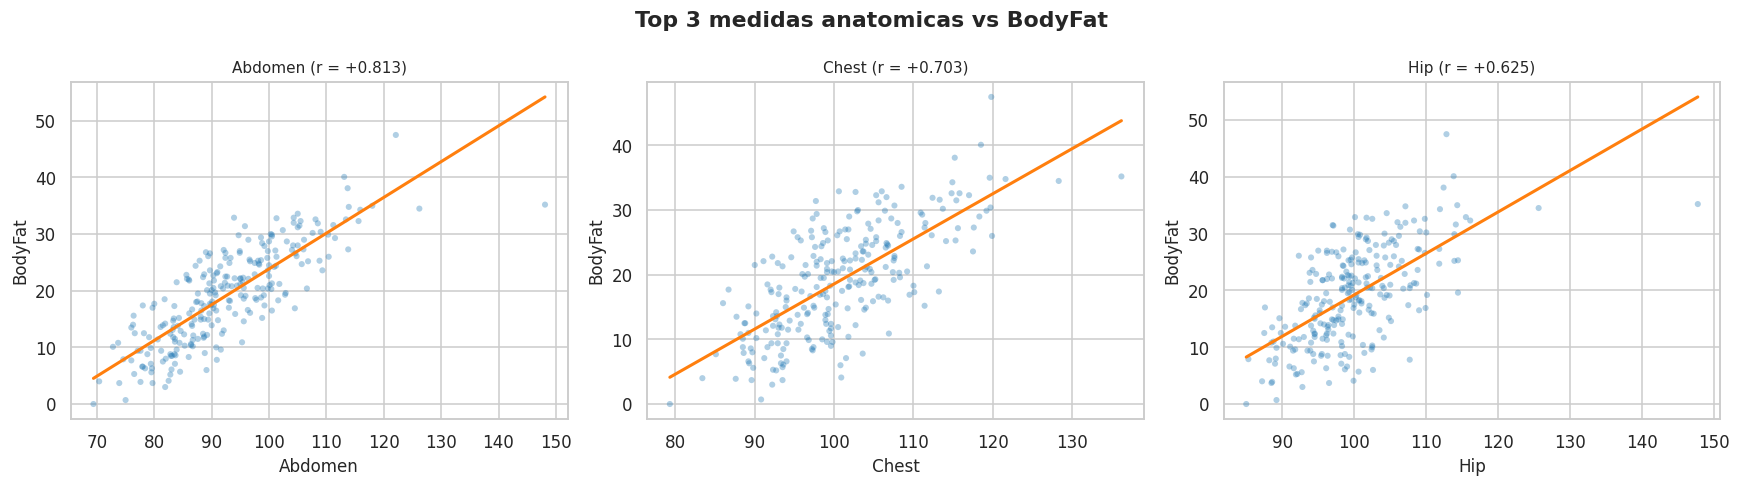

In [30]:
top3_feats = list(top3.index)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Top 3 medidas anatomicas vs BodyFat", fontweight="bold")

for ax, feat in zip(axes, top3_feats):
    ax.scatter(df[feat], df["BodyFat"], alpha=0.35, s=16, color=COLORS["primary"], edgecolors="none")
    m, b = np.polyfit(df[feat], df["BodyFat"], 1)
    xline = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(xline, m * xline + b, color=COLORS["accent"], lw=2)
    ax.set_title(f"{feat} (r = {target_corr[feat]:+.3f})", fontsize=10)
    ax.set_xlabel(feat)
    ax.set_ylabel("BodyFat")

plt.tight_layout()
plt.show()

**Interpretacion:**
- La pendiente confirma la direccion de la relacion (positiva o negativa).
- Si la nube es muy dispersa, el modelo lineal tendra mayor error.
- Estas tres variables son candidatas para un protocolo rapido de medicion.

### 1.4 Deteccion de anomalias (consistencia Weight/Height vs perimetros)

La pregunta clave es si las medidas de perimetro son coherentes
con el peso y la estatura. Para ello calculamos indicadores simples:
- **BMI** usando Weight y Height
- **Ratios de perimetro/altura** (Abdomen, Hip, Chest)

Estos indicadores facilitan detectar casos donde las medidas
no encajan entre si (posibles errores de medicion o casos extremos).

In [31]:
df_eda = df.copy()
df_eda["Height_cm"] = df_eda["Height"] * 2.54
df_eda["BMI"] = (df_eda["Weight"] / (df_eda["Height"] ** 2)) * 703

df_eda["Waist_height"] = df_eda["Abdomen"] / df_eda["Height_cm"]
df_eda["Hip_height"] = df_eda["Hip"] / df_eda["Height_cm"]
df_eda["Chest_height"] = df_eda["Chest"] / df_eda["Height_cm"]

ratio_cols = ["BMI", "Waist_height", "Hip_height", "Chest_height"]
ratio_summary = df_eda[ratio_cols].describe().T.round(3)
ratio_summary

,count,mean,std,min,25%,50%,75%,max
BMI,252.0,25.940,9.558,18.016,23.033,25.092,27.332,165.602
Waist_height,252.0,0.522,0.081,0.397,0.476,0.514,0.552,1.392
Hip_height,252.0,0.563,0.072,0.491,0.536,0.555,0.579,1.541
Chest_height,252.0,0.568,0.072,0.459,0.534,0.558,0.590,1.415


**Interpretacion:**
- BMI resume la relacion peso/estatura; valores extremos son alertas.
- Las razones perimetro/altura permiten comparar personas de distinta talla.
- Si un caso tiene ratios muy altos con BMI bajo (o viceversa), se considera inconsistente.

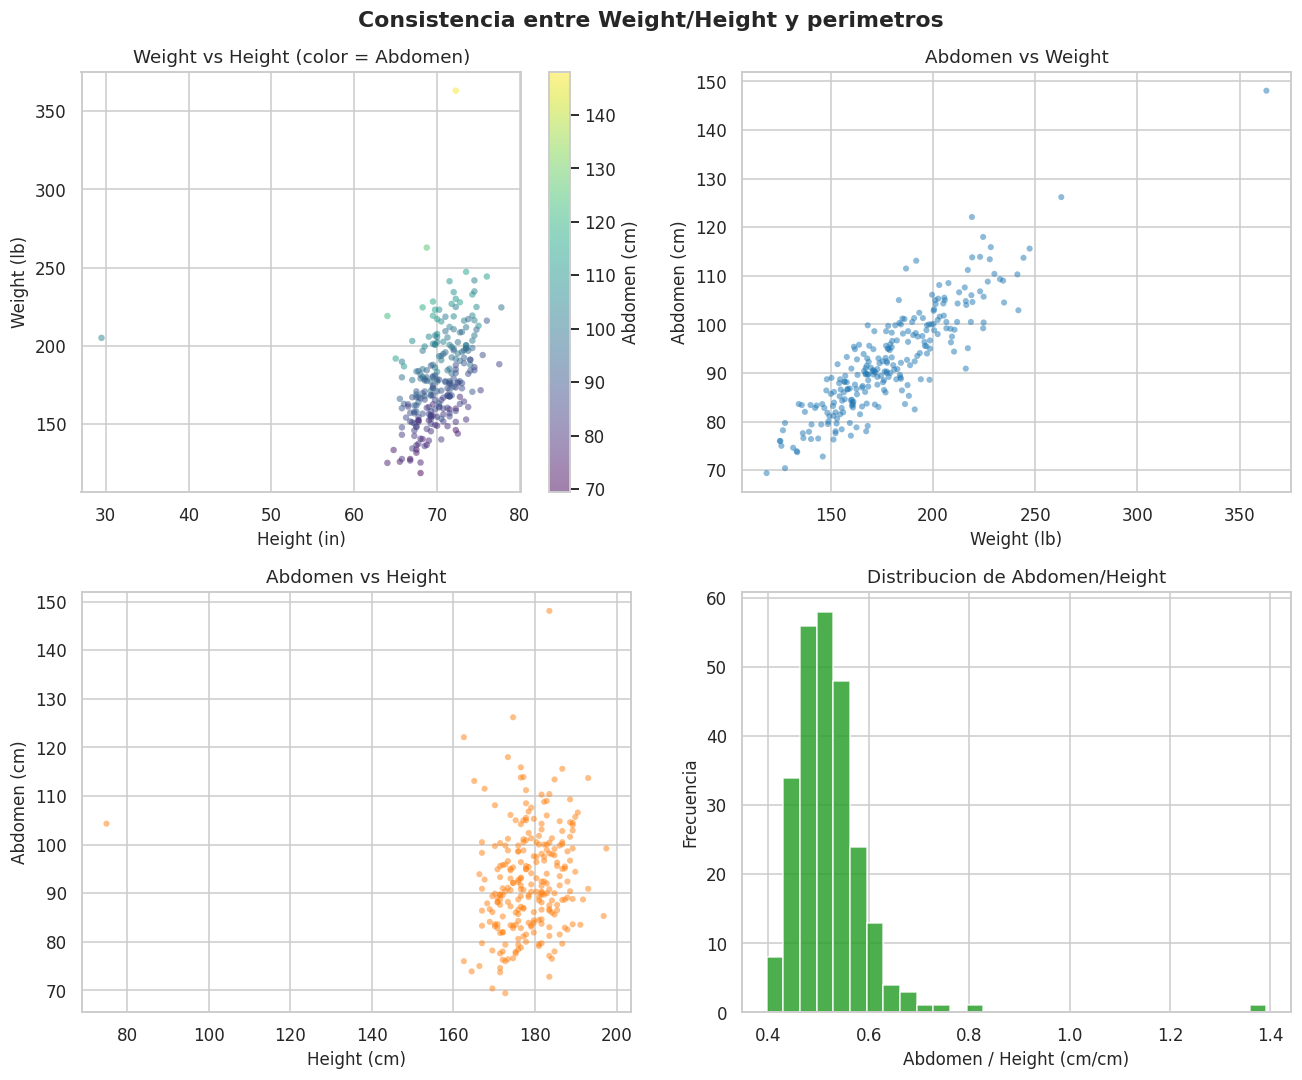

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Consistencia entre Weight/Height y perimetros", fontweight="bold")

sc = axes[0, 0].scatter(
    df_eda["Height"], df_eda["Weight"],
    c=df_eda["Abdomen"], cmap="viridis", s=18, alpha=0.5, edgecolors="none"
 )
axes[0, 0].set_xlabel("Height (in)")
axes[0, 0].set_ylabel("Weight (lb)")
axes[0, 0].set_title("Weight vs Height (color = Abdomen)")
plt.colorbar(sc, ax=axes[0, 0], label="Abdomen (cm)")

axes[0, 1].scatter(df_eda["Weight"], df_eda["Abdomen"], s=16, alpha=0.5, color=COLORS["primary"], edgecolors="none")
axes[0, 1].set_xlabel("Weight (lb)")
axes[0, 1].set_ylabel("Abdomen (cm)")
axes[0, 1].set_title("Abdomen vs Weight")

axes[1, 0].scatter(df_eda["Height_cm"], df_eda["Abdomen"], s=16, alpha=0.5, color=COLORS["accent"], edgecolors="none")
axes[1, 0].set_xlabel("Height (cm)")
axes[1, 0].set_ylabel("Abdomen (cm)")
axes[1, 0].set_title("Abdomen vs Height")

axes[1, 1].hist(df_eda["Waist_height"], bins=30, color=COLORS["ok"], edgecolor="white", alpha=0.85)
axes[1, 1].set_title("Distribucion de Abdomen/Height")
axes[1, 1].set_xlabel("Abdomen / Height (cm/cm)")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Interpretacion:**
- Se observa una tendencia general: a mayor peso, mayor perimetro abdominal.
- La relacion abdomen/altura muestra un rango compacto, con pocos extremos.
- Los puntos alejados de la nube principal se marcan como posibles anomalias.

In [33]:
def iqr_bounds(s, factor=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

rows = []
for col in ratio_cols:
    lo, hi = iqr_bounds(df_eda[col])
    mask = (df_eda[col] < lo) | (df_eda[col] > hi)
    rows.append({
        "feature": col,
        "outliers": int(mask.sum()),
        "pct": round(mask.mean() * 100, 2),
        "low": round(lo, 3),
        "high": round(hi, 3),
    })

outlier_tbl = pd.DataFrame(rows).set_index("feature")
outlier_tbl

,outliers,pct,low,high
feature,,,,
BMI,5,1.98,16.586,33.780
Waist_height,6,2.38,0.361,0.667
Hip_height,6,2.38,0.471,0.644
Chest_height,8,3.17,0.449,0.675


In [34]:
df_eda["z_BMI"] = (df_eda["BMI"] - df_eda["BMI"].mean()) / df_eda["BMI"].std()
df_eda["z_waist_height"] = (df_eda["Waist_height"] - df_eda["Waist_height"].mean()) / df_eda["Waist_height"].std()
df_eda["anomaly_score"] = df_eda[["z_BMI", "z_waist_height"]].abs().max(axis=1)

anomalias = df_eda.sort_values("anomaly_score", ascending=False).head(8)[
    ["Age", "Weight", "Height", "Abdomen", "Hip", "BMI", "Waist_height", "anomaly_score"]
].round(3)

anomalias

,Age,Weight,Height,Abdomen,Hip,BMI,Waist_height,anomaly_score
41,44,205.00,29.50,104.3,115.5,165.602,1.392,14.613
38,46,363.15,72.25,148.1,147.7,48.906,0.807,3.503
215,51,219.00,64.00,122.1,112.8,37.587,0.751,2.816
40,45,262.75,68.75,126.2,125.6,39.080,0.723,2.467
35,49,191.75,65.00,113.1,113.8,31.905,0.685,2.005
241,65,224.50,68.25,118.0,114.3,33.882,0.681,1.951
249,72,186.75,66.00,111.5,101.7,30.139,0.665,1.760
168,35,228.25,69.50,115.9,111.9,33.220,0.657,1.655


**Interpretacion:**
- La tabla IQR muestra cuantas observaciones estan fuera de los limites esperados.
- La lista de anomalias combina BMI y ratio abdomen/altura para detectar casos extremos.
- Estos casos no se eliminan; se tratan con capping en la fase de preparacion.

---
## Fase 3: Data Preparation — Preparar datos para modelado

En esta fase limpiamos duplicados, controlamos outliers con capping IQR
y definimos el set de variables para los modelos de regresion y clasificacion.
**Density** se conserva solo para analisis, pero se excluye del entrenamiento.

### 3.1 Limpieza basica y definicion de variables

Definimos el objetivo (BodyFat) y las variables anatomicas predictoras.
Eliminamos duplicados y dejamos Density fuera del entrenamiento para evitar leakage.

In [35]:
df_prep = df.copy()

n0 = len(df_prep)
df_prep = df_prep.drop_duplicates().reset_index(drop=True)
print(f"Duplicados eliminados: {n0 - len(df_prep)}")

TARGET = "BodyFat"
PRED_COLS = [
    "Age", "Weight", "Height", "Neck", "Chest", "Abdomen", "Hip", "Thigh",
    "Knee", "Ankle", "Biceps", "Forearm", "Wrist"
 ]

print(f"Target: {TARGET}")
print(f"Predictores anatomicos: {len(PRED_COLS)} variables")
print("Se excluye Density para evitar leakage.")

Duplicados eliminados: 0
Target: BodyFat
Predictores anatomicos: 13 variables
Se excluye Density para evitar leakage.


**Interpretacion:**
- El set de predictores incluye edad, peso, altura y perimetros.
- Density se conserva para analisis, pero no puede usarse para entrenar.
- El objetivo (BodyFat) se mantiene intacto, sin transformaciones.

### 3.2 Capping IQR para outliers

Aplicamos capping IQR solo a las variables predictoras para reducir
el impacto de valores extremos sin eliminar observaciones.

In [36]:
def iqr_cap(df_in, cols, factor=1.5):
    out = df_in.copy()
    log = []
    for col in cols:
        q1, q3 = out[col].quantile(0.25), out[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - factor * iqr, q3 + factor * iqr
        n = int(((out[col] < lo) | (out[col] > hi)).sum())
        out[col] = out[col].clip(lo, hi)
        if n > 0:
            log.append({"feature": col, "recortados": n, "low": lo, "high": hi})
    return out, pd.DataFrame(log)

df_prep, cap_log = iqr_cap(df_prep, PRED_COLS)
print(f"Capping aplicado a {len(PRED_COLS)} variables.")
cap_log.head(8)

Capping aplicado a 13 variables.


,feature,recortados,low,high
0,Weight,2,102.0000,254.0000
1,Height,1,62.2500,78.2500
2,Neck,3,31.8625,43.9625
3,Chest,2,77.8125,121.9125
4,Abdomen,3,62.4500,121.4500
5,Hip,3,83.4625,115.5625
6,Thigh,4,46.4750,71.8750
7,Knee,3,32.5500,44.3500


**Interpretacion:**
- El capping reduce la influencia de casos extremos sin perder registros.
- Los limites IQR quedan documentados en la tabla.
- Esto mejora la estabilidad de los modelos sin alterar BodyFat.

### 3.3 Train/Test split y estandarizacion

Dividimos en entrenamiento y prueba (80/20).
La estandarizacion se aplica para los modelos lineales y para tener
comparaciones justas entre algoritmos.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_prep[PRED_COLS].values
y = df_prep[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
 )

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print("Estandarizacion lista para modelos lineales.")

Train: 201 | Test: 51
Estandarizacion lista para modelos lineales.


**Interpretacion:**
- La division 80/20 deja un test set no visto para evaluar generalizacion.
- El scaler se ajusta solo con train para evitar leakage.
- Los datos estan listos para la fase de regresion.

---
## Fase 4: Modeling — Regresion (prediccion continua)

Entrenamos tres modelos con el mismo set de predictores anatomicos:
- Regresion Lineal Multiple (linea base)
- Random Forest Regressor
- XGBoost Regressor

El objetivo es comparar su rendimiento con MAE y $R^2$.

### 4.1 Modelos y tuning sencillo

Usamos pipelines para asegurar que el escalado se aplique solo donde
corresponde. El tuning es ligero para mantener tiempos razonables.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost no disponible. Instala con: pip install xgboost")

# Pipelines
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
 ])

rf_pipe = Pipeline([
    ("scaler", "passthrough"),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
 ])

rf_param = {
    "model__n_estimators": [150, 300, 500],
    "model__max_depth": [None, 6, 10, 16],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.6],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param, n_iter=10, cv=5,
    scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1
 )

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
print("Mejores hiperparametros RF:")
print(rf_search.best_params_)

if HAS_XGB:
    xgb_pipe = Pipeline([
        ("scaler", "passthrough"),
        ("model", XGBRegressor(
            random_state=42, objective="reg:squarederror", eval_metric="rmse"
        ))
    ])
    xgb_param = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    }
    xgb_search = RandomizedSearchCV(
        xgb_pipe, xgb_param, n_iter=10, cv=5,
        scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1
    )
    xgb_search.fit(X_train, y_train)
    xgb_best = xgb_search.best_estimator_
    print("Mejores hiperparametros XGB:")
    print(xgb_search.best_params_)
else:
    xgb_best = None

Mejores hiperparametros RF:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.6, 'model__max_depth': 6}
Mejores hiperparametros XGB:
{'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.85}


**Interpretacion:**
- El tuning busca reducir MAE en validacion cruzada.
- El modelo lineal sirve como referencia simple y explicable.
- RF y XGB agregan no linealidad y suelen capturar mejor la complejidad corporal.

## Fase 5: Evaluation — Regresion
### 5.1 Evaluacion en test y validacion cruzada

Comparamos MAE y $R^2$ en el conjunto de prueba y el promedio en 5-fold CV.

In [39]:
def eval_test(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    return mae, r2

def eval_cv(model, X_all, y_all, cv=5):
    r2 = cross_val_score(model, X_all, y_all, cv=cv, scoring="r2")
    mae = -cross_val_score(model, X_all, y_all, cv=cv, scoring="neg_mean_absolute_error")
    return r2, mae

X_full = df_prep[PRED_COLS].values
y_full = df_prep[TARGET].values

models = [("Regresion Lineal", lr_pipe), ("Random Forest", rf_best)]
if HAS_XGB and xgb_best is not None:
    models.append(("XGBoost", xgb_best))

rows = []
for name, model in models:
    mae_test, r2_test = eval_test(model, X_train, y_train, X_test, y_test)
    r2_cv, mae_cv = eval_cv(model, X_full, y_full, cv=5)
    rows.append({
        "Modelo": name,
        "MAE_test": mae_test,
        "R2_test": r2_test,
        "MAE_CV_mean": mae_cv.mean(),
        "MAE_CV_std": mae_cv.std(),
        "R2_CV_mean": r2_cv.mean(),
        "R2_CV_std": r2_cv.std(),
    })

res_reg = pd.DataFrame(rows).set_index("Modelo").round(4)
res_reg

,MAE_test,R2_test,MAE_CV_mean,MAE_CV_std,R2_CV_mean,R2_CV_std
Modelo,,,,,,
Regresion Lineal,2.9784,0.7244,3.6001,0.3446,0.6620,0.1766
Random Forest,3.1833,0.6731,3.9819,0.2280,0.5907,0.1877
XGBoost,3.3127,0.6340,4.0162,0.2653,0.5906,0.1992


In [40]:
best_mae = res_reg["MAE_test"].idxmin()
best_r2 = res_reg["R2_test"].idxmax()

print(f"Mejor MAE (test): {best_mae}")
print(f"Mejor R2 (test): {best_r2}")
print("MAE esta en porcentaje de BodyFat.")

Mejor MAE (test): Regresion Lineal
Mejor R2 (test): Regresion Lineal
MAE esta en porcentaje de BodyFat.


**Interpretacion:**
- El mejor modelo es el que logra menor MAE y mayor $R^2$ en test.
- La CV permite verificar que el rendimiento no depende de una sola particion.
- Si RF/XGB superan a la linea base, confirman ventaja de modelos no lineales.

### 5.2 Importancia de variables (interpretabilidad)

Comparamos coeficientes estandarizados y feature_importances_ para detectar
la zona corporal mas informativa.

In [41]:
lr_pipe.fit(X_train, y_train)
lr_coef = pd.Series(lr_pipe.named_steps["model"].coef_, index=PRED_COLS)
lr_coef_std = lr_coef / lr_coef.abs().max()

rf_imp = pd.Series(rf_best.named_steps["model"].feature_importances_, index=PRED_COLS)
rf_imp_std = rf_imp / rf_imp.max()

if HAS_XGB and xgb_best is not None:
    xgb_imp = pd.Series(xgb_best.named_steps["model"].feature_importances_, index=PRED_COLS)
    xgb_imp_std = xgb_imp / xgb_imp.max()
else:
    xgb_imp_std = None

imp_df = pd.DataFrame({
    "LR_coef_std": lr_coef_std,
    "RF_imp_std": rf_imp_std,
    "XGB_imp_std": xgb_imp_std
}).sort_values("RF_imp_std", ascending=False)

imp_df

,LR_coef_std,RF_imp_std,XGB_imp_std
Abdomen,1.000000,1.000000,1.000000
Chest,-0.141968,0.299832,0.068228
Weight,-0.064221,0.132013,0.144741
Hip,-0.063461,0.091094,0.081019
Height,-0.063102,0.085326,0.131730
Age,0.105090,0.049850,0.093318
Biceps,0.075279,0.045930,0.072054
Neck,-0.076266,0.045448,0.069366
Knee,-0.025285,0.044774,0.074159
Wrist,-0.161531,0.041976,0.116084


In [42]:
top_lr = lr_coef.abs().idxmax()
top_rf = rf_imp.idxmax()
top_xgb = xgb_imp_std.idxmax() if xgb_imp_std is not None else None

print(f"Top LR (coef): {top_lr}")
print(f"Top RF (importancia): {top_rf}")
if top_xgb:
    print(f"Top XGB (importancia): {top_xgb}")

Top LR (coef): Abdomen
Top RF (importancia): Abdomen
Top XGB (importancia): Abdomen


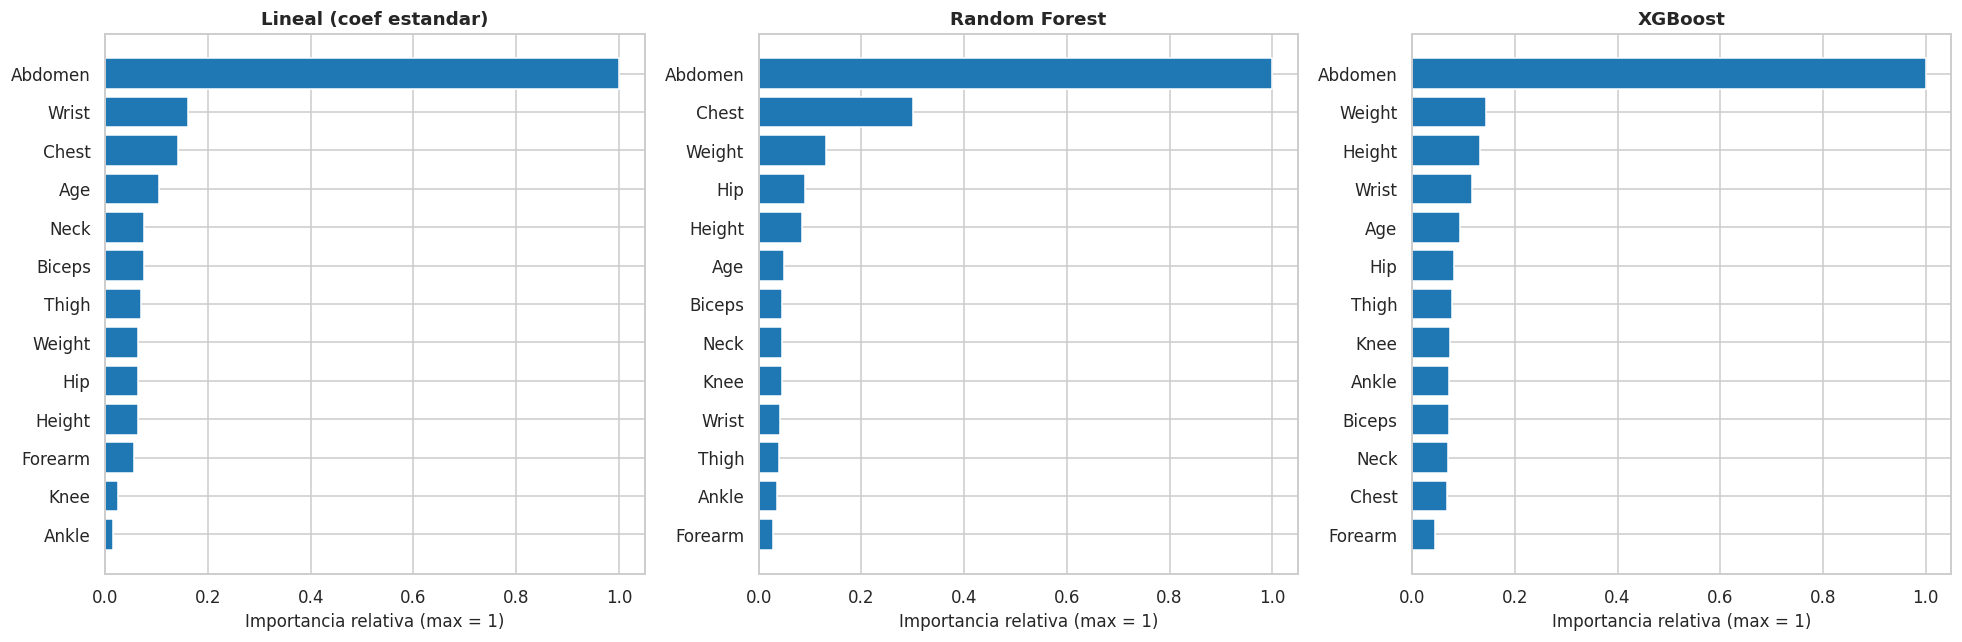

In [43]:
if xgb_imp_std is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    cols = ["LR_coef_std", "RF_imp_std", "XGB_imp_std"]
    titles = ["Lineal (coef estandar)", "Random Forest", "XGBoost"]
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    cols = ["LR_coef_std", "RF_imp_std"]
    titles = ["Lineal (coef estandar)", "Random Forest"]

for ax, col, title in zip(axes, cols, titles):
    vals = imp_df[col].abs().sort_values()
    ax.barh(vals.index, vals.values, color=COLORS["primary"], edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Importancia relativa (max = 1)")

plt.tight_layout()
plt.show()

**Interpretacion:**
- Si los tres modelos coinciden en la misma zona (por ejemplo Abdomen),
  se refuerza como medida clave para un protocolo rapido.
- Diferencias entre modelos son normales: la lineal mira impacto global,
  los arboles priorizan splits informativos.
- Este resultado alimenta la pregunta de "una sola medida" del examen.

---
## Fase 4: Modeling — Clasificacion (diagnostico automatizado)

Creamos la variable **High_Risk** para detectar clientes con riesgo alto
de grasa corporal (BodyFat > 25). Los modelos no pueden usar BodyFat ni Density
como predictors, porque seria fuga de informacion.

### 4.2 Ingenieria de caracteristicas: High_Risk

Definimos el umbral clinico y preparamos el set de entrenamiento.
Se conserva el mismo conjunto de variables anatomicas (PRED_COLS).

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score

df_clf = df_prep.copy()
df_clf["High_Risk"] = (df_clf["BodyFat"] > 25).astype(int)

dist = df_clf["High_Risk"].value_counts()
dist_pct = (df_clf["High_Risk"].value_counts(normalize=True) * 100).round(1)
display(pd.DataFrame({"count": dist, "pct": dist_pct}))

Xc = df_clf[PRED_COLS].values
yc = df_clf["High_Risk"].values

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.20, random_state=42, stratify=yc
 )

print("Features usadas (sin BodyFat ni Density):")
print(PRED_COLS)

,count,pct
High_Risk,,
0,186,73.8
1,66,26.2


Features usadas (sin BodyFat ni Density):
['Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']


**Interpretacion:**
- High_Risk resume el riesgo clinico con un umbral simple y explicable.
- La particion es estratificada para mantener el balance en train/test.
- Confirmamos que BodyFat y Density no se usan como entrada.

## Fase 5: Evaluation — Clasificacion

Entrenamos los clasificadores y evaluamos con matriz de confusion y F1.
El foco clinico es minimizar falsos negativos (clientes en riesgo no detectados).

In [45]:
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=300, solver="liblinear"))
 ])

rf_clf = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1
 )

if HAS_XGB:
    from xgboost import XGBClassifier
    xgb_clf = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        random_state=42, eval_metric="logloss",
        objective="binary:logistic"
    )
else:
    xgb_clf = None

clf_models = [("Logistica", logit_pipe), ("Random Forest", rf_clf)]
if xgb_clf is not None:
    clf_models.append(("XGBoost", xgb_clf))

rows = []
cms = {}
for name, model in clf_models:
    model.fit(Xc_train, yc_train)
    pred = model.predict(Xc_test)
    cm = confusion_matrix(yc_test, pred)
    f1 = f1_score(yc_test, pred)
    fn = int(cm[1, 0])
    fp = int(cm[0, 1])
    rows.append({"Modelo": name, "F1": f1, "FN": fn, "FP": fp})
    cms[name] = cm

res_clf = pd.DataFrame(rows).set_index("Modelo").sort_values("FN")
res_clf

,F1,FN,FP
Modelo,,,
XGBoost,0.80,3,2
Logistica,0.75,4,2
Random Forest,0.75,4,2


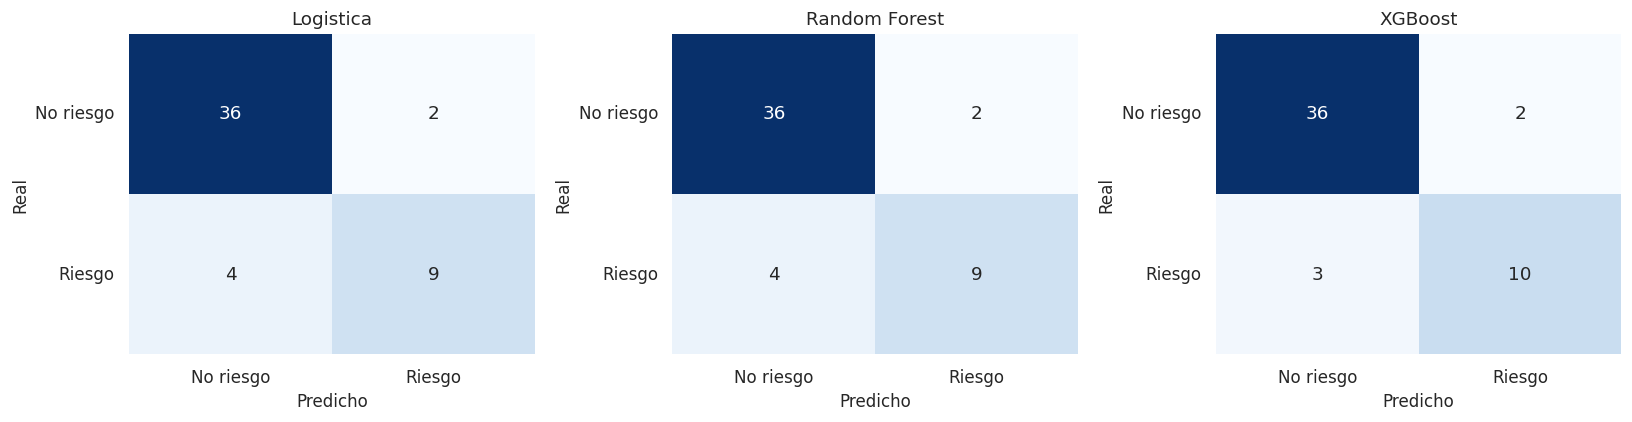

In [46]:
fig, axes = plt.subplots(1, len(cms), figsize=(5 * len(cms), 4))
if len(cms) == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_xticklabels(["No riesgo", "Riesgo"])
    ax.set_yticklabels(["No riesgo", "Riesgo"], rotation=0)

plt.tight_layout()
plt.show()

**Interpretacion:**
- El mejor modelo clinico es el que tiene menos falsos negativos.
- F1 resume el balance entre precision y recall, pero el criterio primario es FN.
- Si XGBoost o RF reducen FN respecto a Logistica, son preferibles para alertas.

---
## Fase 6: Deployment y cierre — Reflexion del caso

**1) Por que es critico eliminar Density y BodyFat en la fase de clasificacion?**
Density y BodyFat contienen la respuesta real (o un proxy directo). Si se usan
como entradas, el modelo aprende con informacion que no tendra en produccion,
generando sobreajuste y una falsa sensacion de exactitud (leakage).

**2) Si solo se puede medir una zona, cual deberia ser?**
Segun el ranking top 3 y la tabla de importancias, la zona que aparece de forma
consistente como mas informativa es la que se recomienda medir es el abdomen. Esto es coherente
con la fisica del cuerpo: una zona con alta correlacion lineal ofrece mayor poder
predictivo con un solo dato.

**3) Que ventajas mostraron los modelos de arboles?**
Random Forest y XGBoost capturan relaciones no lineales y combinaciones entre
medidas corporales. Por eso suelen reducir MAE y aumentar $R^2$ respecto a la
regresion lineal, especialmente cuando las relaciones no son estrictamente lineales.